In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extraer información de la base de datos

In [2]:
# Cargar primera base de datos
raw_data = pd.read_excel('R_booooo\data\DATOS HISTÓRICOS 2023_2024_TODAS ESTACIONES_ITESM.xlsx')
raw_data.shape

(13872, 240)

In [3]:
# Cargar segunda base de datos
ex_rest_24 = pd.read_excel('R_booooo\data\DATOS HISTÓRICOS 2024_TODAS ESTACIONES.xlsx', sheet_name=None)
rest_24 = pd.concat(ex_rest_24.values(), axis=1)
rest_24.shape

(8784, 240)

# Limpieza, Tipo de Datos, Valores Faltantes

In [39]:
# Eliminar columnas vacias o redundantes
raw_data.dropna(how='all', axis=1, inplace=True)
rest_24.drop(columns='Fecha y hora', inplace=True)

# Establecer nans y cambiar nombre de la primera columna
raw_data.replace("", np.nan, inplace=True)
raw_data.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)

# Retirar primeras dos filas con metadatos
raw_data = raw_data.drop([0, 1])

# Resetear index
raw_data = raw_data.reset_index(drop=True)

# Hacer datetime columna Date
raw_data["Date"] = pd.to_datetime(raw_data["Date"])
rest_24['Date'] = pd.to_datetime(rest_24['Date'])

# Hacer Columnas Numéricas
for col in raw_data.columns:
    if col != "Date":
        raw_data[col] = pd.to_numeric(raw_data[col], errors="coerce")

# Resetear el indice como la fecha
raw_data.set_index("Date", inplace=True)
rest_24.set_index('Date', inplace=True)

# Combinar ambos dataframes en uno
nombre_columnas = raw_data.columns
rest_24_1 = rest_24.loc['2024-08-01 01:00:00':]
rest_24_1.columns = nombre_columnas
raw_data = pd.concat([raw_data, rest_24_1], axis=0)

# Revisar valores nulos
print(raw_data.shape)
raw_data.isna().sum()

(17541, 225)


SURESTE          1005
SURESTE.1         407
SURESTE.2         172
SURESTE.3         173
SURESTE.4         486
                 ... 
NOROESTE 3.10    4476
NOROESTE 3.11     764
NOROESTE 3.12     246
NOROESTE 3.13    2105
NOROESTE 3.14     320
Length: 225, dtype: int64

In [ ]:
# Mostrar el dataset
raw_data.head()

,SURESTE,SURESTE.1,SURESTE.2,SURESTE.3,SURESTE.4,SURESTE.5,SURESTE.6,SURESTE.7,SURESTE.8,SURESTE.9,...,NOROESTE 3.5,NOROESTE 3.6,NOROESTE 3.7,NOROESTE 3.8,NOROESTE 3.9,NOROESTE 3.10,NOROESTE 3.11,NOROESTE 3.12,NOROESTE 3.13,NOROESTE 3.14
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,2.37,54.5,32.6,87.1,3.0,110.0,68.00,721.7,0.0,68.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-01 01:00:00,2.12,38.7,30.3,68.9,3.0,116.0,67.18,721.5,0.0,72.0,...,246.0,NaN,707.4,0.0,59.0,2.9,0.0,14.14,65.3,95.0
2023-01-01 02:00:00,2.05,38.7,28.8,67.4,3.0,117.0,75.12,721.1,0.0,71.0,...,239.0,NaN,707.0,0.0,59.0,3.2,0.0,14.11,60.9,90.0
2023-01-01 03:00:00,2.50,60.5,29.1,89.4,3.0,135.0,82.81,720.8,0.0,68.0,...,275.0,NaN,706.8,0.0,59.0,2.3,0.0,14.08,58.1,84.0
2023-01-01 04:00:00,1.94,42.3,25.7,67.7,NaN,132.0,59.56,720.7,0.0,73.0,...,NaN,NaN,706.8,0.0,58.0,1.8,0.0,12.94,61.4,87.0


In [ ]:
# Mostrar el dataset
raw_data.tail()

,SURESTE,SURESTE.1,SURESTE.2,SURESTE.3,SURESTE.4,SURESTE.5,SURESTE.6,SURESTE.7,SURESTE.8,SURESTE.9,...,NOROESTE 3.5,NOROESTE 3.6,NOROESTE 3.7,NOROESTE 3.8,NOROESTE 3.9,NOROESTE 3.10,NOROESTE 3.11,NOROESTE 3.12,NOROESTE 3.13,NOROESTE 3.14
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-31 19:00:00,0.20,2.8,7.6,10.4,55.0,57.0,14.98,722.9,0.0,23.0,...,59.0,NaN,732.0,0.0,38.0,3.3,NaN,17.7,1.3,132.0
2024-12-31 20:00:00,0.20,2.6,6.9,9.4,62.0,65.0,15.88,723.7,0.0,25.0,...,67.0,NaN,732.0,0.0,50.0,3.0,NaN,15.3,1.0,5.0
2024-12-31 21:00:00,0.21,2.6,12.9,15.5,56.0,54.0,51.77,724.4,0.0,26.0,...,77.0,NaN,733.0,0.0,53.0,3.1,NaN,14.1,1.4,86.0
2024-12-31 22:00:00,0.20,2.7,16.0,18.6,47.0,92.0,NaN,724.7,0.0,28.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 23:00:00,0.19,2.6,10.5,13.0,44.0,129.0,68.40,725.0,0.0,37.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Primero utilizamos interpolación de datos faltantes en espacios más pequeños, usando una interpolación lineal para no más de 3 datos faltantes consecutivos
data_interpolate = (
    raw_data
    .interpolate(method="time", limit=3, limit_direction="both", limit_area="inside")
)

data_interpolate.isna().sum()

SURESTE           775
SURESTE.1          26
SURESTE.2          26
SURESTE.3          26
SURESTE.4          65
                 ... 
NOROESTE 3.10    4177
NOROESTE 3.11     410
NOROESTE 3.12      31
NOROESTE 3.13    1720
NOROESTE 3.14      64
Length: 225, dtype: int64

In [ ]:
# Para rellenar espacios grandes de missing values utilizando un KNNIMPUTE 
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(data_interpolate), columns=data_interpolate.columns, index=data_interpolate.index)
df_imputed.isna().sum()

SURESTE          0
SURESTE.1        0
SURESTE.2        0
SURESTE.3        0
SURESTE.4        0
                ..
NOROESTE 3.10    0
NOROESTE 3.11    0
NOROESTE 3.12    0
NOROESTE 3.13    0
NOROESTE 3.14    0
Length: 225, dtype: int64

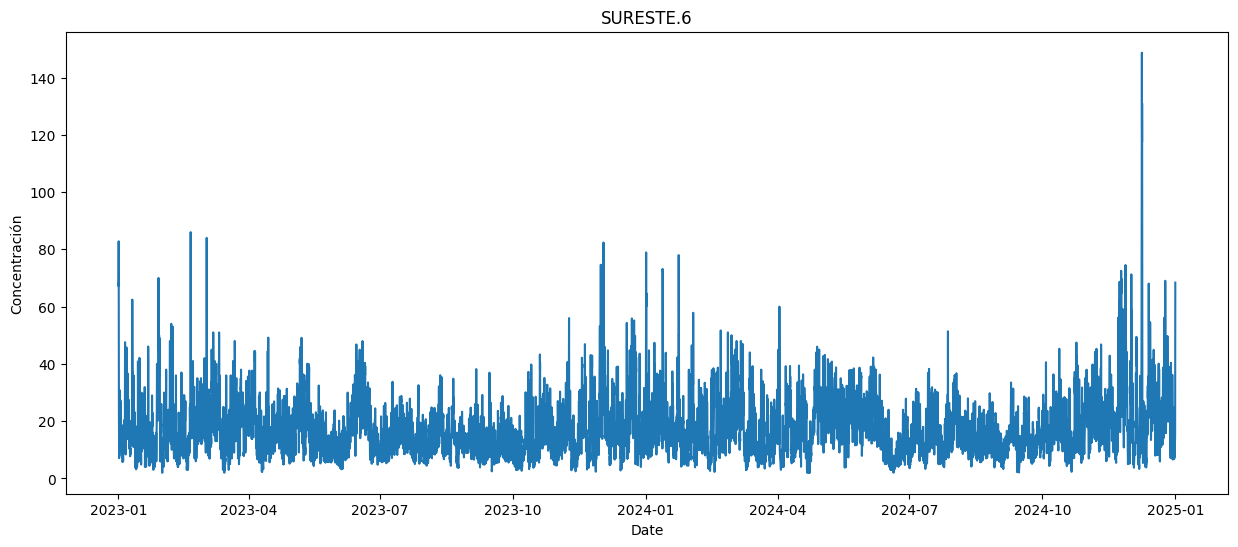

In [ ]:
# Ejemplo de los datos en una variable 
plt.figure(figsize=(15,6))
plt.plot(df_imputed['SURESTE.6'])
plt.title('SURESTE.6')
plt.ylabel('Concentración')
plt.xlabel('Date')
plt.show()

In [ ]:
# Hacer archivo .csv
import os
dataframe_etapa_1 = df_imputed
dataframe_etapa_1.to_csv('DF_E1.csv')